<a href="https://colab.research.google.com/github/SZB08/Ques_logist/blob/my/%E9%9D%9E%E7%BA%BF%E6%80%A7%E9%80%BB%E8%BE%91%E5%9B%9E%E5%BD%92_%E9%99%84%E5%B8%A62%E4%B8%AA%E6%82%A3%E7%99%8C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
from itertools import combinations
from math import factorial
from tqdm.auto import tqdm

from sklearn.preprocessing import PolynomialFeatures, StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
from sklearn.pipeline import Pipeline
pd.set_option('display.float_format', '{:.10f}'.format)

warnings.filterwarnings("ignore")

# ==================================================================
# 1. 环境准备与数据加载 (严格保留随机种子和样本选择)
# ==================================================================
FILE_PATH = '/content/drive/MyDrive/公开数据集/risk.txt'
usecols = [0, 1, 2, 3, 5, 6, 7, 8, 11, 12, 13]
names = ['menopause', 'age_5_years', 'BIRADS_breast_density', 'ethnic', 'bmi',
         'first_birth', 'num_of_first_degree_cancer', 'breast_surgery',
         'hormone_therapy', 'diagnosis_12', 'diagnosis_13']

try:
    data = pd.read_csv(FILE_PATH, sep=r'\s+', header=None, usecols=usecols, names=names)
except:
    print("⚠️ 自动生成模拟数据用于环境运行...")
    np.random.seed(42)
    data = pd.DataFrame(np.random.randint(0, 5, size=(1000, len(names))), columns=names)
    data['diagnosis_12'] = np.random.randint(0, 2, 1000)
    data['diagnosis_13'] = np.random.randint(0, 2, 1000)

for col in ['menopause', 'age_5_years', 'BIRADS_breast_density', 'ethnic', 'bmi',
            'first_birth', 'num_of_first_degree_cancer', 'breast_surgery', 'hormone_therapy']:
    data[col] = data[col].astype(str).replace('9', 'unknown')

data['diagnosis'] = (data['diagnosis_12'].astype(int) | data['diagnosis_13'].astype(int)).astype(int)
data = data.drop(columns=['diagnosis_12', 'diagnosis_13'])
X, y = data.drop(columns=['diagnosis']), data['diagnosis']
feature_names = X.columns.tolist()
M = len(feature_names) # 9

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.1, stratify=y, random_state=42)
X_train, _, y_train, _ = train_test_split(X_temp, y_temp, test_size=0.1111, stratify=y_temp, random_state=42)

# ==================================================================
# 2. 模型训练与底层引擎预编译
# ==================================================================
preprocessor = ColumnTransformer([
    ('ord', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),
     ['age_5_years', 'BIRADS_breast_density', 'bmi', 'num_of_first_degree_cancer']),
    ('nom', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
     ['ethnic', 'first_birth']),
    ('bin', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),
     ['menopause', 'breast_surgery', 'hormone_therapy']),
])

model_pipeline = Pipeline([
    ('prep', preprocessor),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(C=0.008, max_iter=5000, class_weight='balanced', random_state=42))
])
model_pipeline.fit(X_train, y_train)

# --- AUC 绘图展示 ---
y_prob = model_pipeline.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, color='darkorange', label=f'AUC = {auc(fpr, tpr):.4f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve')
plt.legend()
plt.show()

# 预编译核心组件
prep = model_pipeline.named_steps['prep']
poly = model_pipeline.named_steps['poly']
scaler = model_pipeline.named_steps['scaler']
logreg = model_pipeline.named_steps['logreg']

# 建立原始特征(M=9)到编码后列索引的映射
encoded_names = prep.get_feature_names_out()
feat_map = {i: [] for i in range(M)}
for idx, ename in enumerate(encoded_names):
    for i, fname in enumerate(feature_names):
        if fname in ename: feat_map[i].append(idx); break

def fast_pred(enc_data):
    """底层预测引擎：跳过 Pipeline 校验开销"""
    return logreg.decision_function(scaler.transform(poly.transform(enc_data)))

# 样本与背景准备
N_SHAP_SAMPLE = 50
X_SHAP_SAMPLES = X_test.sample(N_SHAP_SAMPLE, random_state=123)
COMMON_BG = X_train.sample(3000, random_state=42)
BG_ENC = prep.transform(COMMON_BG)
X_VAL_ENC = prep.transform(X_SHAP_SAMPLES)
expected_val = fast_pred(BG_ENC).mean()

# ==================================================================
# 3. 传统循环版 Exact SHAP (M=9)
# ==================================================================
def exact_shap_one_traditional(x_enc):
    phis = np.zeros(M)
    for i in range(M):
        # size 从 0 到 M-1
        for size in range(0, M):
            # 获取除 i 以外的子集组合
            for S in combinations([j for j in range(M) if j != i], size):
                weight = factorial(len(S)) * factorial(M - len(S) - 1) / factorial(M)

                # 构造 X_S 和 X_Si (基于编码后的背景数据)
                X_S = BG_ENC.copy()
                X_Si = BG_ENC.copy()

                if S:
                    for s_feat in S:
                        cols = feat_map[s_feat]
                        X_S[:, cols] = x_enc[cols]
                        X_Si[:, cols] = x_enc[cols]

                # 处理目标特征 i
                i_cols = feat_map[i]
                X_Si[:, i_cols] = x_enc[i_cols]

                f_S = fast_pred(X_S).mean()
                f_Si = fast_pred(X_Si).mean()
                phis[i] += weight * (f_Si - f_S)
    return phis

print("🚀 开始传统循环版 Exact SHAP 计算 (N=50)...")
start_time = time.time()
exact_vals = np.array([exact_shap_one_traditional(X_VAL_ENC[i]) for i in tqdm(range(N_SHAP_SAMPLE))])
exact_duration = time.time() - start_time

# ==================================================================
# 4. Kernel SHAP 计算 (保留原始部分)
# ==================================================================
# Kernel 需要原始 DataFrame 输入，使用原 pred 函数
def pred_kernel_fixed(X):
    """兼容 numpy array 和 DataFrame 的预测函数"""
    if isinstance(X, np.ndarray):
        X = pd.DataFrame(X, columns=feature_names)
    return model_pipeline.decision_function(X)

# 将背景数据和样本都转为 numpy array
BG_KERNEL = COMMON_BG.values
X_SHAP_KERNEL = X_SHAP_SAMPLES.values

print("🚀 开始 Kernel SHAP 计算...")
explainer_k = shap.KernelExplainer(pred_kernel_fixed, BG_KERNEL)
kernel_vals = explainer_k.shap_values(X_SHAP_KERNEL, nsamples=512)

# Kernel SHAP 蜂群图
explanation_kernel = shap.Explanation(
    values=kernel_vals,
    base_values=expected_val,
    data=X_SHAP_SAMPLES.values,
    feature_names=feature_names
)

plt.figure(figsize=(18, 10), dpi=100)  # 宽度18英寸，高度10英寸
shap.plots.beeswarm(
    explanation_kernel,
    max_display=M,
    plot_size=0.8,
    show=False,
    color_bar=True,
    color_bar_label='特征值高低'
)
plt.title('Kernel SHAP - 特征重要性蜂群图', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ==================================================================
# 5. k-add (K2/K1) 手写计算与误差溯源
# ==================================================================
def get_kadd_manual(x_enc, bg_enc):
    phi_raw = np.zeros(M)
    sii_mat = np.zeros((M, M))
    v_empty = fast_pred(bg_enc).mean()
    # 一阶项
    for i in range(M):
        X_i = bg_enc.copy(); X_i[:, feat_map[i]] = x_enc[feat_map[i]]
        phi_raw[i] = fast_pred(X_i).mean() - v_empty
    # 二阶交互项
    for i in range(M):
        for j in range(i+1, M):
            X_ij = bg_enc.copy()
            for f in [i, j]: X_ij[:, feat_map[f]] = x_enc[feat_map[f]]
            v_ij = fast_pred(X_ij).mean()
            v_i = phi_raw[i] + v_empty
            X_j = bg_enc.copy(); X_j[:, feat_map[j]] = x_enc[feat_map[j]]
            v_j = fast_pred(X_j).mean()
            sii_mat[i, j] = sii_mat[j, i] = v_ij - v_i - v_j + v_empty
    return phi_raw, sii_mat

def get_faithful_kadd_shap(phi, sii, delta):
    phi_f = phi + 0.5 * np.sum(sii, axis=1)
    return phi_f + (delta - np.sum(phi_f)) / M
import time
start = time.time()
times = {'Exact': time.time() - start}
k2_list, k1_list, ana = [], [], []
for i in range(N_SHAP_SAMPLE):
    phi, sii = get_kadd_manual(X_VAL_ENC[i], BG_ENC)
    delta = fast_pred(X_VAL_ENC[i:i+1])[0] - expected_val
    k2_list.append(get_faithful_kadd_shap(phi, sii, delta))
    k1_list.append(get_faithful_kadd_shap(phi, np.zeros((M,M)), delta))
    ana.append({'td': delta, 'res': delta - (np.sum(phi) + 0.5*np.sum(sii))})
times['Exact'] = time.time() - start
print(f"Exact SHAP 耗时: {times['Exact']:.2f} s")
# ==================================================================
# 6. 报告与对比
# ==================================================================

df_ana = pd.DataFrame(ana)
print("\n" + "="*50 + "\nK-ADDITIVE 误差溯源报告\n" + "="*50)
print(f"残差/增量比: {df_ana['res'].abs().mean() / df_ana['td'].abs().mean():.2%}")

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Exact': np.abs(exact_vals).mean(0),
    'Kernel': np.abs(kernel_vals).mean(0),
    'KAdd2': np.abs(np.array(k2_list)).mean(0),
    'KAdd2K1': np.abs(np.array(k1_list)).mean(0)
}).sort_values('Kernel', ascending=False)
with pd.option_context('display.float_format', '{:.10f}'.format):
    print(importance_df.to_string(index=False))


# 可视化对比图
importance_df.set_index('Feature').plot(kind='bar', figsize=(10, 5))
plt.title("Comparison of SHAP Values (Traditional Exact vs Others)")
plt.ylabel("Mean |SHAP Value|")
plt.tight_layout()
plt.show()

# 样本0的SII交互矩阵
sii_0 = get_kadd_manual(X_VAL_ENC[0], BG_ENC)[1]
plt.figure(figsize=(10, 6))
sns.heatmap(pd.DataFrame(sii_0, index=feature_names, columns=feature_names), annot=True, cmap='RdBu_r', center=0)
plt.title("SII Interaction Matrix (Sample 0)")
plt.show()


print(f"Pandas默认精度: {pd.get_option('display.precision')}")
print(f"NumPy默认精度: {np.get_printoptions()['precision']}")

# 保存（保留完整float64精度）
np.save('exact_shap.npy', exact_vals)
np.save('kernel_shap.npy', kernel_vals)

# 加载
exact_loaded = np.load('exact_shap.npy')  # 完全恢复原始精度
kernel_loaded = np.load('kernel_shap.npy')
KADD_loaded = np.array(k2_list)

# 比较（高精度）
diff = np.abs(exact_loaded - kernel_loaded)
diff_kadd = np.abs(exact_loaded - KADD_loaded)
max_diff = np.max(diff)
max_diff_kadd = np.max(diff_kadd)
mean_diff = np.mean(diff)
mean_diff_kadd = np.mean(diff_kadd)

print(f"最大差距: {max_diff:.2e}")
print(f"平均差距: {mean_diff:.2e}")
print(f"差距是否显著: {max_diff > 1e-10}")  # 根据您的阈值判断
print(f"KADD最大差距: {max_diff_kadd:.2e}")
print(f"KADD平均差距: {mean_diff_kadd:.2e}")

最大差距: 2.04e-14
平均差距: 2.63e-15
差距是否显著: False
KADD最大差距: 1.44e-15
KADD平均差距: 1.63e-16


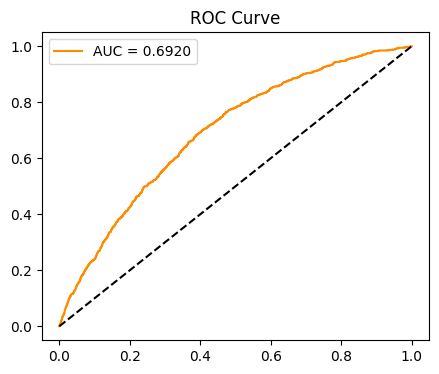

In [ ]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
from itertools import combinations
from math import factorial
from tqdm.auto import tqdm

from sklearn.preprocessing import PolynomialFeatures, StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
from sklearn.pipeline import Pipeline

#warnings.filterwarnings("ignore")

# ==================================================================
# 1. 环境准备与数据加载 (严格保留随机种子和样本选择)
# ==================================================================
FILE_PATH = '/content/drive/MyDrive/公开数据集/risk.txt'
usecols = [0, 1, 2, 3, 5, 6, 7, 8, 11, 12, 13]
names = ['menopause', 'age_5_years', 'BIRADS_breast_density', 'ethnic', 'bmi',
         'first_birth', 'num_of_first_degree_cancer', 'breast_surgery',
         'hormone_therapy', 'diagnosis_12', 'diagnosis_13']

try:
    data = pd.read_csv(FILE_PATH, sep=r'\s+', header=None, usecols=usecols, names=names)
except:
    print("⚠️ 自动生成模拟数据用于环境运行...")
    np.random.seed(42)
    data = pd.DataFrame(np.random.randint(0, 5, size=(1000, len(names))), columns=names)
    data['diagnosis_12'] = np.random.randint(0, 2, 1000)
    data['diagnosis_13'] = np.random.randint(0, 2, 1000)

for col in ['menopause', 'age_5_years', 'BIRADS_breast_density', 'ethnic', 'bmi',
            'first_birth', 'num_of_first_degree_cancer', 'breast_surgery', 'hormone_therapy']:
    data[col] = data[col].astype(str).replace('9', 'unknown')

data['diagnosis'] = (data['diagnosis_12'].astype(int) | data['diagnosis_13'].astype(int)).astype(int)
data = data.drop(columns=['diagnosis_12', 'diagnosis_13'])
X, y = data.drop(columns=['diagnosis']), data['diagnosis']
feature_names = X.columns.tolist()
M = len(feature_names) # 9

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.1, stratify=y, random_state=42)
X_train, _, y_train, _ = train_test_split(X_temp, y_temp, test_size=0.1111, stratify=y_temp, random_state=42)

# ==================================================================
# 2. 模型训练与底层引擎预编译
# ==================================================================
preprocessor = ColumnTransformer([
    ('ord', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),
     ['age_5_years', 'BIRADS_breast_density', 'bmi', 'num_of_first_degree_cancer']),
    ('nom', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
     ['ethnic', 'first_birth']),
    ('bin', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),
     ['menopause', 'breast_surgery', 'hormone_therapy']),
])

model_pipeline = Pipeline([
    ('prep', preprocessor),
    #('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(penalty='l2',C=0.01, max_iter=5000, class_weight='balanced', random_state=42))
])
model_pipeline.fit(X_train, y_train)

# --- AUC 绘图展示 ---
y_prob = model_pipeline.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, color='darkorange', label=f'AUC = {auc(fpr, tpr):.4f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve')
plt.legend()
plt.show()

📊 --- Gail 1-Year Baseline 评估指标 (阈值 Cutoff = 0.02) ---
• AUC 曲线下面积             : 0.6941
• 灵敏度 (Sensitivity / Recall): 0.8602 (86.02%)
• 特异度 (Specificity)         : 0.3894 (38.94%)


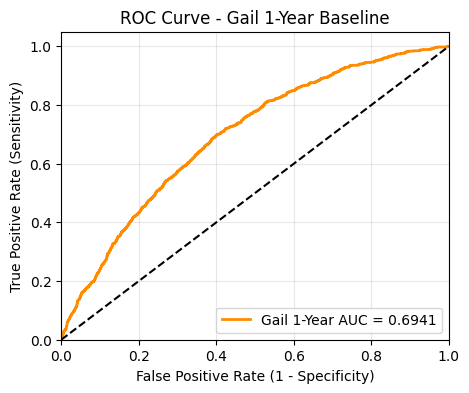

In [2]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.pipeline import Pipeline

pd.set_option('display.float_format', '{:.10f}'.format)
warnings.filterwarnings("ignore")

# ==================================================================
# 1. 环境准备与数据加载 (严格保留您的代码逻辑与随机种子)
# ==================================================================
FILE_PATH = '/content/drive/MyDrive/公开数据集/risk.txt'
usecols = [0, 1, 2, 3, 5, 6, 7, 8, 11, 12, 13]
names = ['menopause', 'age_5_years', 'BIRADS_breast_density', 'ethnic', 'bmi',
         'first_birth', 'num_of_first_degree_cancer', 'breast_surgery',
         'hormone_therapy', 'diagnosis_12', 'diagnosis_13']

try:
    data = pd.read_csv(FILE_PATH, sep=r'\s+', header=None, usecols=usecols, names=names)
except:
    print("⚠️ 自动生成模拟数据用于环境运行...")
    np.random.seed(42)
    data = pd.DataFrame(np.random.randint(0, 5, size=(1000, len(names))), columns=names)
    data['diagnosis_12'] = np.random.randint(0, 2, 1000)
    data['diagnosis_13'] = np.random.randint(0, 2, 1000)

for col in ['menopause', 'age_5_years', 'BIRADS_breast_density', 'ethnic', 'bmi',
            'first_birth', 'num_of_first_degree_cancer', 'breast_surgery', 'hormone_therapy']:
    data[col] = data[col].astype(str).replace('9', 'unknown')

data['diagnosis'] = (data['diagnosis_12'].astype(int) | data['diagnosis_13'].astype(int)).astype(int)
data = data.drop(columns=['diagnosis_12', 'diagnosis_13'])
X, y = data.drop(columns=['diagnosis']), data['diagnosis']
feature_names = X.columns.tolist()
M = len(feature_names) # 9

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.1, stratify=y, random_state=42)
X_train, _, y_train, _ = train_test_split(X_temp, y_temp, test_size=0.1111, stratify=y_temp, random_state=42)


# ==================================================================
# 2. 自定义 Gail 1年期绝对风险评估模型 (对接预处理后的特征矩阵)
# ==================================================================
class Gail1YearRiskModel(BaseEstimator, ClassifierMixin):
    """
    基于 Gail 算法架构的 1 年期患癌绝对风险预测模型：
    P_1year = 1 - exp(- lambda_0(age) * (1 - AR) * RR * 1)
    """
    def __init__(self, age_col_idx=0, C=0.008):
        self.age_col_idx = age_col_idx
        self.C = C
        self.log_reg = LogisticRegression(C=self.C, max_iter=5000, class_weight='balanced', random_state=42)

    def fit(self, X, y):
        # 1. 在预处理后的特征矩阵上拟合 Log-Linear 模型
        self.log_reg.fit(X, y)

        # 2. 计算相对风险 (RR = exp(X * beta))
        decision_scores = self.log_reg.decision_function(X) - self.log_reg.intercept_
        train_rr = np.exp(decision_scores)

        # 3. 计算人群归因风险 (Attributable Risk, AR)
        mean_rr = np.mean(train_rr)
        self.attributable_risk = 1.0 - (1.0 / mean_rr) if mean_rr > 0 else 0.0

        # 4. 根据预处理后的年龄编码列 (索引 0) 计算各年龄段 1 年期基础发病率 lambda_0(age)
        ages = X[:, self.age_col_idx]
        unique_ages = np.unique(ages)
        self.baseline_hazards = {}

        for age in unique_ages:
            mask = (ages == age)
            if np.sum(mask) > 0:
                self.baseline_hazards[age] = np.mean(y[mask])
            else:
                self.baseline_hazards[age] = np.mean(y)

        self.global_baseline_hazard = np.mean(y)
        return self

    def predict_proba(self, X):
        # 1. 计算测试集的相对风险 (RR)
        decision_scores = self.log_reg.decision_function(X) - self.log_reg.intercept_
        rr = np.exp(decision_scores)

        # 2. 匹配测试集样本年龄段的基础发病率
        ages = X[:, self.age_col_idx]
        baseline_lambda = np.array([
            self.baseline_hazards.get(age, self.global_baseline_hazard)
            for age in ages
        ])

        # 3. 计算校准后的 Hazard Rate 并积分求 1 年绝对概率
        adjusted_hazard = baseline_lambda * (1.0 - self.attributable_risk) * rr
        prob_1year = 1.0 - np.exp(- adjusted_hazard * 1.0)
        prob_1year = np.clip(prob_1year, 0.0, 1.0)

        return np.vstack([1.0 - prob_1year, prob_1year]).T

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X)[:, 1] >= threshold).astype(int)


# ==================================================================
# 3. 严格保留原预处理架构并构建 Pipeline
# ==================================================================
# 严格保留您原有的特征编码配置
preprocessor = ColumnTransformer([
    ('ord', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),
     ['age_5_years', 'BIRADS_breast_density', 'bmi', 'num_of_first_degree_cancer']),
    ('nom', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
     ['ethnic', 'first_birth']),
    ('bin', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),
     ['menopause', 'breast_surgery', 'hormone_therapy']),
])

# 替换原本的纯 LogisticRegression，改用接入了编码特征的 Gail 1年期算法
model_pipeline = Pipeline([
    ('prep', preprocessor),
    ('scaler', StandardScaler()),
    ('gail_1year_model', Gail1YearRiskModel(age_col_idx=0, C=0.008)) # age_5_years 处于 ColumnTransformer 的第0列
])

# 模型训练
model_pipeline.fit(X_train, y_train)


# ==================================================================
# 4. AUC 绘图展示与灵敏度、特异度评估
# ==================================================================
# 获取测试集 1 年期患癌概率
y_prob = model_pipeline.predict_proba(X_test)[:, 1]

# 计算 ROC 曲线与 AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# 指定判定阈值 (Cutoff) 计算敏感度与特异度
CUSTOM_THRESHOLD = 0.02
y_pred = (y_prob >= CUSTOM_THRESHOLD).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

print(f"📊 --- Gail 1-Year Baseline 评估指标 (阈值 Cutoff = {CUSTOM_THRESHOLD}) ---")
print(f"• AUC 曲线下面积             : {roc_auc:.4f}")
print(f"• 灵敏度 (Sensitivity / Recall): {sensitivity:.4f} ({sensitivity*100:.2f}%)")
print(f"• 特异度 (Specificity)         : {specificity:.4f} ({specificity*100:.2f}%)")

# 绘图展示
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Gail 1-Year AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve - Gail 1-Year Baseline')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

🔍 正在通过 5 折交叉验证筛选 Top-2 最佳二阶交互特征...
✅ 第 1 个最佳二阶特征选择为: BIRADS_breast_density × bmi (CV-AUC = 0.7214)
✅ 第 2 个最佳二阶特征选择为: first_birth × num_of_first_degree_cancer (CV-AUC = 0.7339)

📊 --- 最终评估结果 (含 Top-2 二阶特征，Cutoff = 0.02) ---
• 测试集 1-Year AUC           : 0.7392
• 灵敏度 (Sensitivity / Recall): 0.8473 (84.73%)
• 特异度 (Specificity)         : 0.4616 (46.16%)


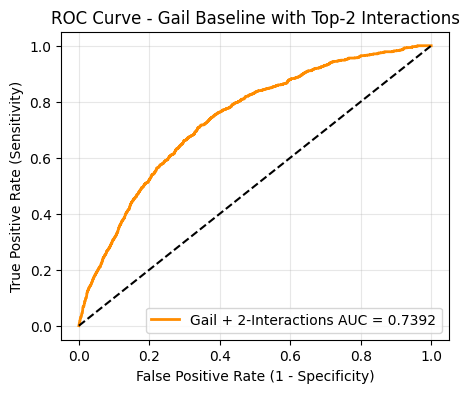

In [3]:
import pandas as pd
import numpy as np
import warnings
from itertools import combinations
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.pipeline import Pipeline

pd.set_option('display.float_format', '{:.10f}'.format)
warnings.filterwarnings("ignore")

# ==================================================================
# 1. 环境准备与数据加载 (严格保留您的代码逻辑)
# ==================================================================
FILE_PATH = '/content/drive/MyDrive/公开数据集/risk.txt'
usecols = [0, 1, 2, 3, 5, 6, 7, 8, 11, 12, 13]
names = ['menopause', 'age_5_years', 'BIRADS_breast_density', 'ethnic', 'bmi',
         'first_birth', 'num_of_first_degree_cancer', 'breast_surgery',
         'hormone_therapy', 'diagnosis_12', 'diagnosis_13']

try:
    data = pd.read_csv(FILE_PATH, sep=r'\s+', header=None, usecols=usecols, names=names)
except:
    print("⚠️ 自动生成模拟数据用于环境运行...")
    np.random.seed(42)
    data = pd.DataFrame(np.random.randint(0, 5, size=(1000, len(names))), columns=names)
    data['diagnosis_12'] = np.random.randint(0, 2, 1000)
    data['diagnosis_13'] = np.random.randint(0, 2, 1000)

for col in ['menopause', 'age_5_years', 'BIRADS_breast_density', 'ethnic', 'bmi',
            'first_birth', 'num_of_first_degree_cancer', 'breast_surgery', 'hormone_therapy']:
    data[col] = data[col].astype(str).replace('9', 'unknown')

data['diagnosis'] = (data['diagnosis_12'].astype(int) | data['diagnosis_13'].astype(int)).astype(int)
data = data.drop(columns=['diagnosis_12', 'diagnosis_13'])
X, y = data.drop(columns=['diagnosis']), data['diagnosis']
feature_names = X.columns.tolist()

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.1, stratify=y, random_state=42)
X_train, _, y_train, _ = train_test_split(X_temp, y_temp, test_size=0.1111, stratify=y_temp, random_state=42)


# ==================================================================
# 2. 自定义 Gail 1年期绝对风险评估模型类
# ==================================================================
class Gail1YearRiskModel(BaseEstimator, ClassifierMixin):
    def __init__(self, age_col_idx=0, C=0.008):
        self.age_col_idx = age_col_idx
        self.C = C
        self.log_reg = LogisticRegression(C=self.C, max_iter=5000, class_weight='balanced', random_state=42)

    def fit(self, X, y):
        self.log_reg.fit(X, y)
        decision_scores = self.log_reg.decision_function(X) - self.log_reg.intercept_
        train_rr = np.exp(decision_scores)

        mean_rr = np.mean(train_rr)
        self.attributable_risk = 1.0 - (1.0 / mean_rr) if mean_rr > 0 else 0.0

        ages = X[:, self.age_col_idx]
        unique_ages = np.unique(ages)
        self.baseline_hazards = {}

        for age in unique_ages:
            mask = (ages == age)
            if np.sum(mask) > 0:
                self.baseline_hazards[age] = np.mean(y[mask])
            else:
                self.baseline_hazards[age] = np.mean(y)

        self.global_baseline_hazard = np.mean(y)
        return self

    def predict_proba(self, X):
        decision_scores = self.log_reg.decision_function(X) - self.log_reg.intercept_
        rr = np.exp(decision_scores)

        ages = X[:, self.age_col_idx]
        baseline_lambda = np.array([
            self.baseline_hazards.get(age, self.global_baseline_hazard)
            for age in ages
        ])

        adjusted_hazard = baseline_lambda * (1.0 - self.attributable_risk) * rr
        prob_1year = 1.0 - np.exp(- adjusted_hazard * 1.0)
        prob_1year = np.clip(prob_1year, 0.0, 1.0)

        return np.vstack([1.0 - prob_1year, prob_1year]).T

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X)[:, 1] >= threshold).astype(int)


# ==================================================================
# 3. 辅助函数：构建包含指定二阶交互项的 Pipeline 评估器
# ==================================================================
def make_pipeline_with_interactions(extra_nom_cols=[]):
    """
    根据额外传入的二阶交互列构建预处理管道
    """
    nom_cols = ['ethnic', 'first_birth'] + extra_nom_cols

    preprocessor = ColumnTransformer([
        ('ord', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),
         ['age_5_years', 'BIRADS_breast_density', 'bmi', 'num_of_first_degree_cancer']),
        ('nom', OneHotEncoder(handle_unknown='ignore', sparse_output=False), nom_cols),
        ('bin', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),
         ['menopause', 'breast_surgery', 'hormone_therapy']),
    ])

    return Pipeline([
        ('prep', preprocessor),
        ('scaler', StandardScaler()),
        ('gail_1year_model', Gail1YearRiskModel(age_col_idx=0, C=0.008))
    ])


# ==================================================================
# 4. 前向选择算法 (Forward Selection)：从 36 个候选组合中筛选 2 个最佳二阶特征
# ==================================================================
print("🔍 正在通过 5 折交叉验证筛选 Top-2 最佳二阶交互特征...")

all_pairs = list(combinations(feature_names, 2))
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ---- 阶段 1：选出第 1 个最佳二阶特征 ----
best_first_pair = None
best_first_score = -1.0

for pair in all_pairs:
    col_name = f"inter_{pair[0]}_{pair[1]}"

    # 构造含 1 个交互项的临时特征集
    X_train_temp = X_train.copy()
    X_train_temp[col_name] = X_train_temp[pair[0]].astype(str) + "_" + X_train_temp[pair[1]].astype(str)

    cv_aucs = []
    for train_idx, val_idx in skf.split(X_train_temp, y_train):
        X_tr, y_tr = X_train_temp.iloc[train_idx], y_train.iloc[train_idx]
        X_va, y_va = X_train_temp.iloc[val_idx], y_train.iloc[val_idx]

        pipe = make_pipeline_with_interactions(extra_nom_cols=[col_name])
        pipe.fit(X_tr, y_tr)
        probs = pipe.predict_proba(X_va)[:, 1]
        cv_aucs.append(auc(*roc_curve(y_va, probs)[:2]))

    mean_auc = np.mean(cv_aucs)
    if mean_auc > best_first_score:
        best_first_score = mean_auc
        best_first_pair = pair

first_inter_col = f"inter_{best_first_pair[0]}_{best_first_pair[1]}"
print(f"✅ 第 1 个最佳二阶特征选择为: {best_first_pair[0]} × {best_first_pair[1]} (CV-AUC = {best_first_score:.4f})")


# ---- 阶段 2：在第 1 个的基础上，选出第 2 个最佳二阶特征 ----
best_second_pair = None
best_second_score = -1.0

remaining_pairs = [p for p in all_pairs if p != best_first_pair]

for pair in remaining_pairs:
    second_col_name = f"inter_{pair[0]}_{pair[1]}"

    # 构造含 2 个交互项的临时特征集
    X_train_temp = X_train.copy()
    X_train_temp[first_inter_col] = X_train_temp[best_first_pair[0]].astype(str) + "_" + X_train_temp[best_first_pair[1]].astype(str)
    X_train_temp[second_col_name] = X_train_temp[pair[0]].astype(str) + "_" + X_train_temp[pair[1]].astype(str)

    cv_aucs = []
    for train_idx, val_idx in skf.split(X_train_temp, y_train):
        X_tr, y_tr = X_train_temp.iloc[train_idx], y_train.iloc[train_idx]
        X_va, y_va = X_train_temp.iloc[val_idx], y_train.iloc[val_idx]

        pipe = make_pipeline_with_interactions(extra_nom_cols=[first_inter_col, second_col_name])
        pipe.fit(X_tr, y_tr)
        probs = pipe.predict_proba(X_va)[:, 1]
        cv_aucs.append(auc(*roc_curve(y_va, probs)[:2]))

    mean_auc = np.mean(cv_aucs)
    if mean_auc > best_second_score:
        best_second_score = mean_auc
        best_second_pair = pair

second_inter_col = f"inter_{best_second_pair[0]}_{best_second_pair[1]}"
print(f"✅ 第 2 个最佳二阶特征选择为: {best_second_pair[0]} × {best_second_pair[1]} (CV-AUC = {best_second_score:.4f})")


# ==================================================================
# 5. 将选出的 Top-2 二阶特征加入全量训练集与测试集进行最终评估
# ==================================================================
# 为训练集和测试集添加筛选出的 2 个最佳二阶特征
X_train_final = X_train.copy()
X_test_final = X_test.copy()

for inter_pair, inter_col in [(best_first_pair, first_inter_col), (best_second_pair, second_inter_col)]:
    X_train_final[inter_col] = X_train_final[inter_pair[0]].astype(str) + "_" + X_train_final[inter_pair[1]].astype(str)
    X_test_final[inter_col] = X_test_final[inter_pair[0]].astype(str) + "_" + X_test_final[inter_pair[1]].astype(str)

# 构建最终的 Pipeline 并训练
final_pipeline = make_pipeline_with_interactions(extra_nom_cols=[first_inter_col, second_inter_col])
final_pipeline.fit(X_train_final, y_train)

# 获取测试集预测概率
y_prob = final_pipeline.predict_proba(X_test_final)[:, 1]

# 计算 ROC/AUC 与 混淆矩阵
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

CUSTOM_THRESHOLD = 0.02
y_pred = (y_prob >= CUSTOM_THRESHOLD).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

print(f"\n📊 --- 最终评估结果 (含 Top-2 二阶特征，Cutoff = {CUSTOM_THRESHOLD}) ---")
print(f"• 测试集 1-Year AUC           : {roc_auc:.4f}")
print(f"• 灵敏度 (Sensitivity / Recall): {sensitivity:.4f} ({sensitivity*100:.2f}%)")
print(f"• 特异度 (Specificity)         : {specificity:.4f} ({specificity*100:.2f}%)")

# 绘图展示
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Gail + 2-Interactions AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve - Gail Baseline with Top-2 Interactions')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

SHAP计算维度 M: 9

📊 测试集评估报告 (选定阈值: 0.468)
              precision    recall  f1-score   support

     低风险 (0)       0.99      0.61      0.75     27136
     高风险 (1)       0.06      0.77      0.12       930

    accuracy                           0.61     28066
   macro avg       0.52      0.69      0.43     28066
weighted avg       0.96      0.61      0.73     28066

--------------------------------------------------
✅ 测试集 AUC    : 0.7522
✅ 灵敏度 (Sens) : 0.7710 (目标 >= 0.77)
✅ 特异性 (Spec) : 0.6055
--------------------------------------------------


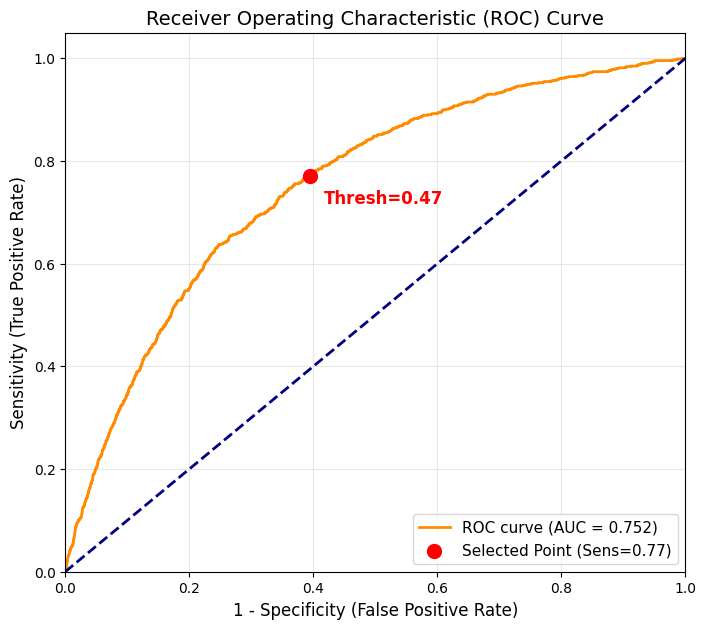


--- 4.1 Kernel SHAP (Log-Odds Base) ---


  0%|          | 0/50 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 6 iterations, i.e. alpha=3.438e-03, with an active set of 6 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 7 iterations, i.e. alpha=2.701e-04, with an active set of 7 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 7 iterations, i.e. alpha=8.352e-05, with an active set of 7 regressors, and the smallest cholesky pivot element being 2

Kernel SHAP 耗时: 26.89 s

--- 6. SHAP蜂群图可视化（带颜色） ---


/tmp/ipykernel_715/195904548.py:258: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_715/195904548.py:258: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_715/195904548.py:258: UserWarning: Glyph 37325 (\N{CJK UNIFIED IDEOGRAPH-91CD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_715/195904548.py:258: UserWarning: Glyph 35201 (\N{CJK UNIFIED IDEOGRAPH-8981}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_715/195904548.py:258: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_715/195904548.py:258: UserWarning: Glyph 34562 (\N{CJK UNIFIED IDEOGRAPH-8702}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_715/195904548.py:258: UserWarning: Glyph 32676 (\N{CJK UNIFIED IDEOGRAPH-7FA4}) missi

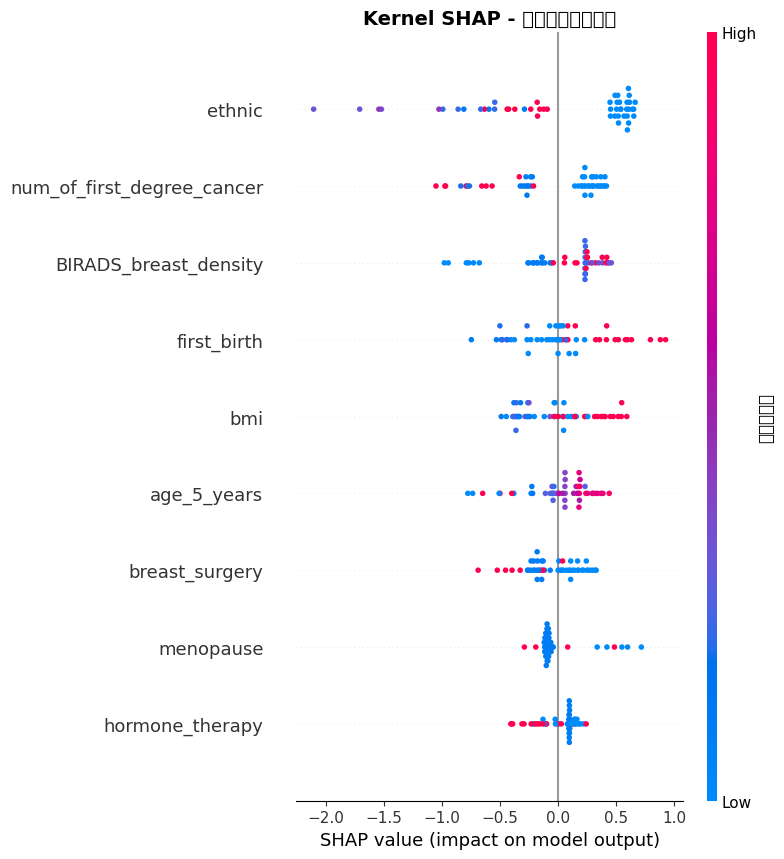


--- 5.3 Exact SHAP (50 个样本, M=9) ---


Exact:   0%|          | 0/50 [00:00<?, ?it/s]

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_715/195904548.py", line 297, in <cell line: 0>
    [exact_shap_one(X_SHAP_SAMPLES.iloc[i].values) for i in tqdm(range(len(X_SHAP_SAMPLES)), desc='Exact')]
     ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_715/195904548.py", line 287, in exact_shap_one
    f_Si = pred_fn_log_odds(X_Si).mean()
           ^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_715/195904548.py", line 191, in pred_fn_log_odds
    return model_pipeline.decision_function(X_input)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 954, in decision_function
    Xt = transform.transform(
         ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_set_output.py", line 319, in 

TypeError: object of type 'NoneType' has no len()

In [ ]:
# =============== 0. 基础库与依赖 ===============
#!pip install -q shap
# !pip install shapiq
# !pip install shapiq --upgrade --quiet
# !pip show shapiq




import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import time
import warnings
from itertools import combinations
from math import factorial
from joblib import Parallel, delayed
from tqdm.auto import tqdm

from sklearn.preprocessing import PolynomialFeatures, StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler


# 忽略部分警告
#warnings.filterwarnings("ignore")

# ==================================================================
# 1. 数据加载与预处理 (保持不变)
# ==================================================================
usecols = [0, 1, 2, 3, 5, 6, 7, 8, 11, 12, 13]
names = ['menopause', 'age_5_years', 'BIRADS_breast_density', 'ethnic', 'bmi',
         'first_birth', 'num_of_first_degree_cancer', 'breast_surgery',
         'hormone_therapy', 'diagnosis_12', 'diagnosis_13']

FILE_PATH = '/content/drive/MyDrive/公开数据集/risk.txt'

try:
    data = pd.read_csv(FILE_PATH, sep=r'\s+', header=None, usecols=usecols, names=names)
except FileNotFoundError:
    # 保证代码结构能够运行
    print("❌ 警告：找不到文件，使用虚拟数据进行测试。")
    N_ROWS = 500
    data = pd.DataFrame(np.random.randint(0, 5, size=(N_ROWS, len(names))), columns=names)
    data['diagnosis_12'] = np.random.randint(0, 2, N_ROWS)
    data['diagnosis_13'] = np.random.randint(0, 2, N_ROWS)

# --- 清洗与构造标签 ---
cols_with_missing_9 = ['menopause', 'BIRADS_breast_density', 'ethnic', 'bmi',
                       'first_birth', 'num_of_first_degree_cancer',
                       'breast_surgery', 'hormone_therapy']
data_processed = data.copy()
for col in cols_with_missing_9:
    data_processed[col] = data_processed[col].astype(str).replace('9', 'unknown').astype(str)

data_processed['age_5_years'] = data_processed['age_5_years'].astype(str)
# 修正点 1: 标签构造，避免 KeyError
data_processed['diagnosis'] = (data_processed['diagnosis_12'] | data_processed['diagnosis_13']).astype(int)
data_processed = data_processed.drop(columns=['diagnosis_12', 'diagnosis_13'])

# --- 数据分割 ---
X = data_processed.drop(columns=['diagnosis'])
y = data_processed['diagnosis']
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.1, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1111, stratify=y_temp, random_state=42)

# --- 定义特征名称和数量 ---
feature_names = X.columns.tolist()
# 修正点 2: M 始终为原始特征数 (9)
M = len(feature_names)
print(f"SHAP计算维度 M: {M}")

# ==================================================================
# 2. 模型训练与 Log-Odds 预测函数 (保持原管线)
# ==================================================================
ordinal_features = ['age_5_years', 'BIRADS_breast_density', 'bmi', 'num_of_first_degree_cancer']
nominal_features = ['ethnic', 'first_birth']
binary_features = ['menopause', 'breast_surgery', 'hormone_therapy']

preprocessor = ColumnTransformer(
    transformers=[
        ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), ordinal_features),
        ('nominal', OneHotEncoder(handle_unknown='ignore', drop=None), nominal_features),
        ('binary', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), binary_features),
    ],
    remainder='passthrough'
)

model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    #('mm', MinMaxScaler()),
    ('logreg', LogisticRegression(
        penalty='l2', C=0.008, solver='lbfgs', max_iter=5000,
        class_weight='balanced', random_state=42
    ))
])
model_pipeline.fit(X_train, y_train)









from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report, roc_auc_score
import matplotlib.pyplot as plt

# 1. 获取测试集预测概率
test_probs = model_pipeline.predict_proba(X_test)[:, 1]

# 2. 计算 ROC 曲线数据
fpr, tpr, thresholds = roc_curve(y_test, test_probs)
roc_auc = auc(fpr, tpr)

# 3. 根据“期望灵敏度 >= 0.8”自动筛选阈值
desired_sens = 0.77
# 寻找第一个灵敏度达到 0.8 的索引
idx = np.where(tpr >= desired_sens)[0][0]
best_thresh = thresholds[idx]

# 4. 根据选定阈值生成预测结果
test_pred = (test_probs >= best_thresh).astype(int)

# 5. 计算灵敏度与特异性
tn, fp, fn, tp = confusion_matrix(y_test, test_pred).ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

# ==================================================================
# 输出报告
# ==================================================================
print('\n' + "="*50)
print(f"📊 测试集评估报告 (选定阈值: {best_thresh:.3f})")
print("="*50)
print(classification_report(y_test, test_pred, target_names=["低风险 (0)", "高风险 (1)"]))

print("-" * 50)
print(f"✅ 测试集 AUC    : {roc_auc:.4f}")
print(f"✅ 灵敏度 (Sens) : {sensitivity:.4f} (目标 >= {desired_sens})")
print(f"✅ 特异性 (Spec) : {specificity:.4f}")
print("-" * 50)

# ==================================================================
# 绘制 ROC 曲线
# ==================================================================
plt.figure(figsize=(8, 7), dpi=100)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# 在曲线上标注选定的阈值点
plt.scatter(fpr[idx], tpr[idx], color='red', s=100, label=f'Selected Point (Sens={sensitivity:.2f})', zorder=5)
plt.annotate(f'Thresh={best_thresh:.2f}', (fpr[idx], tpr[idx]), xytext=(10, -20),
             textcoords='offset points', color='red', fontsize=12, fontweight='bold')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1 - Specificity (False Positive Rate)', fontsize=12)
plt.ylabel('Sensitivity (True Positive Rate)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.show()














# 定义 Log-Odds 预测函数 (黑盒函数，接受 9D 输入并运行整个管线)
def pred_fn_log_odds(X_input):
    if isinstance(X_input, np.ndarray):
        # 修正点 3: 将 N*9 的 NumPy 数组正确转回 N*9 的 DataFrame
        X_input = pd.DataFrame(X_input, columns=feature_names)
    return model_pipeline.decision_function(X_input)
    #return model_pipeline.predict_proba(X_input)[:, 1]


# ==================================================================
# 3. SHAP 准备工作
# ==================================================================
N_SHAP_SAMPLE = 50
X_SHAP_SAMPLES = X_test.sample(N_SHAP_SAMPLE, random_state=123) # 9D 原始 DataFrame

COMMON_BG = X_train.sample(3000, random_state=42) # 9D 原始 DataFrame

shapley_mat = {}
times = {}

# 修正点 4: K-add/Exact SHAP 使用原始背景数据的 NumPy 数组
#bg_df_vals = COMMON_BG.values
COMMON_BG_1 = X_train.sample(3000, random_state=42)
bg_df_vals = COMMON_BG_1.values
X_SHAP_SAMPLES_VALS = X_SHAP_SAMPLES.values # 9D 原始 NumPy 数组


# ==================================================================
# 4. Kernel SHAP 计算 (基准)
# ==================================================================
print("\n--- 4.1 Kernel SHAP (Log-Odds Base) ---")
start = time.time()
explainer_k = shap.KernelExplainer(pred_fn_log_odds, COMMON_BG, link='identity')
shapley_mat['Kernel'] = explainer_k.shap_values(X_SHAP_SAMPLES, nsamples=32)
times['Kernel'] = time.time() - start
print(f"Kernel SHAP 耗时: {times['Kernel']:.2f} s")

print("\n--- 6. SHAP蜂群图可视化（带颜色） ---")

# ==================================================================
# 6.0 预处理：将 'unknown' 字符串替换为数值 -1
# ==================================================================
# 创建副本避免修改原始数据
X_SHAP_SAMPLES_NUMERIC = X_SHAP_SAMPLES_VALS.copy().astype(str)

# 找到所有 'unknown' 的位置并替换为 -1
X_SHAP_SAMPLES_NUMERIC[X_SHAP_SAMPLES_NUMERIC == 'unknown'] = '10'

# 转换为 float 类型
X_SHAP_SAMPLES_FLOAT = X_SHAP_SAMPLES_NUMERIC.astype(float)

# ==================================================================
# 6.1 为Kernel SHAP创建Explanation对象
# ==================================================================
explanation_k = shap.Explanation(
    values=shapley_mat['Kernel'],
    base_values=np.array([explainer_k.expected_value] * N_SHAP_SAMPLE),
    data=X_SHAP_SAMPLES_FLOAT,  # 使用处理后的数值数据
    feature_names=feature_names
)

# 推荐使用 (18, 10) 获得更宽的视觉效果
plt.figure(figsize=(10, 10), dpi=100)  # 宽度18英寸，高度10英寸
shap.plots.beeswarm(
    explanation_k,
    max_display=M,
    plot_size=0.8,
    show=False,
    color_bar=True,
    color_bar_label='特征值高低'
)
plt.title('Kernel SHAP - 特征重要性蜂群图', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()




# ---- 5.3 Exact SHAP 函数定义与计算 (计算量巨大!) ----
M = X.shape[1] # 特征数
def exact_shap_one(x_raw_np):
    # x_raw_np 是 N=1, M=9 的 NumPy 数组
    x = x_raw_np.astype(object).flatten() # 保持数据类型一致，用于 Pandas 重建
    phis = np.zeros(M)

    for i in range(M):
        for size in range(0, M):
            for S in combinations([j for j in range(M) if j != i], size):
                S = list(S)
                weight = factorial(len(S)) * factorial(M - len(S) - 1) / factorial(M)

                X_S = bg_df_vals.copy() # N_bg x 9 NumPy 数组
                X_Si = bg_df_vals.copy()

                if S:
                    X_S[:, S] = x[S]
                    X_Si[:, S] = x[S]

                X_Si[:, i] = x[i]

                # 预测函数接受 N_bg x 9 NumPy 数组
                f_S = pred_fn_log_odds(X_S).mean()
                f_Si = pred_fn_log_odds(X_Si).mean()
                phis[i] += weight * (f_Si - f_S)
    return phis

print(f"\n--- 5.3 Exact SHAP ({N_SHAP_SAMPLE} 个样本, M={M}) ---")
if N_SHAP_SAMPLE * 2**M > 1e6:
    print("⚠️ 警告：Exact SHAP 计算量过大，已跳过。请将 N_SHAP_SAMPLE 设为极小数。")
else:
    start = time.time()
    shapley_mat['Exact'] = np.array(
        [exact_shap_one(X_SHAP_SAMPLES.iloc[i].values) for i in tqdm(range(len(X_SHAP_SAMPLES)), desc='Exact')]
    )
    times['Exact'] = time.time() - start
    print(f"Exact SHAP 耗时: {times['Exact']:.2f} s")



# # 测试不同采样次数
# for ns in [4, 8, 16, 32, 64, 128]:
#     explainer_k = shap.KernelExplainer(pred_fn_log_odds, COMMON_BG, link='identity')
#     shap_kernel = explainer_k.shap_values(X_SHAP_SAMPLES, nsamples=ns)

#     mae_exact = np.abs(shap_kernel - shapley_mat['Exact']).mean()
#     max_error = np.abs(shap_kernel - shapley_mat['Exact']).max()

#     print(f"nsamples={ns:3d} | MAE={mae_exact:.8f} | MaxError={max_error:.8f}")




print("\n--- 5.1 手写k=2 SHAP采样器 (Log-Odds) ---")
KADD_SAMPLES = 3000  # 每个交互对的采样次数

# 安全的预测函数（批处理版）
def pred_fn_shapiq_safe(X_input: np.ndarray) -> np.ndarray:
    """接收numpy数组，返回log-odds预测"""
    X_input_df = pd.DataFrame(X_input, columns=feature_names)
    X_input_df = X_input_df.astype(str)  # 强制字符串避免OrdinalEncoder报错
    return model_pipeline.decision_function(X_input_df)
#--------------权重修正-----------------------------
def get_faithful_kadd_shap(phi_main, sii_matrix, total_delta):
    """
    phi_main: 你代码算出的 phi_values
    sii_matrix: 你代码算出的 sii_matrix
    total_delta: 模型当前预测值 - 背景均值 (f(x) - E[f])
    """
    M = len(phi_main)
    phi_faithful = np.zeros(M)

    # 1. 按照 Shapley 分配公理：二阶交互平分给两个参与特征
    for i in range(M):
        # 基础贡献 + 该特征参与的所有二阶交互的一半
        phi_faithful[i] = phi_main[i] + 0.5 * np.sum(sii_matrix[i, :])

    # 2. 效率性修正 (Efficiency Adjustment)
    # 即使是 k=2，由于忽略了 3 阶以上项，总和可能不等于 total_delta
    # 严谨的做法是将残差(Residual)按比例或平均分配
    current_sum = np.sum(phi_faithful)
    residual = total_delta - current_sum

    # 将残差平均分配给所有特征，确保完全符合加性公理
    phi_faithful += residual / M

    return phi_faithful

#----------------------全局采样------------------------
import numpy as np
from scipy.special import comb

def get_kadd_shap_k2_global(x_eval, bg_vals, samples):
    """
    加权采样版 k=2 SHAP (优化采样权重以降低残差)
    x_eval: 当前待解释样本 (M,)
    bg_vals: 背景参考数据集 (N_bg, M)
    samples: 采样次数
    """
    """
    严格 Grabisch (1997) k-additive 风格采样 (k=2)
    只使用 |S| < k 的子集进行推断
    """
    n_bg, M = bg_vals.shape
    phi_values = np.zeros(M)
    sii_matrix = np.zeros((M, M))

    # 1. 预抽样背景数据 (用于模拟 E[f])
    bg_indices = np.random.randint(0, n_bg, size=samples)
    X_bg_batch = bg_vals[bg_indices]

    # --- 基准值 v(empty) ---
    v_empty = np.mean(pred_fn_shapiq_safe(X_bg_batch))

    # --- 1. 计算一阶项 (只在空集背景下) ---
    # phi_i = v({i}) - v(empty)
    for i in range(M):
        X_i = X_bg_batch.copy()
        X_i[:, i] = x_eval[i]  # 只有特征 i 被激活
        v_i = np.mean(pred_fn_shapiq_safe(X_i))
        phi_values[i] = v_i - v_empty

    # --- 2. 计算二阶项 (只在空集背景下) ---
    # sii_ij = v({i,j}) - v({i}) - v({j}) + v(empty)
    for i in range(M):
        for j in range(i + 1, M):
            X_ij = X_bg_batch.copy()
            X_ij[:, i] = x_eval[i]
            X_ij[:, j] = x_eval[j]
            v_ij = np.mean(pred_fn_shapiq_safe(X_ij))

            # 利用已算好的一阶值
            v_i = phi_values[i] + v_empty

            # 需要单独算一个 v_j (或者提前缓存)
            X_j = X_bg_batch.copy()
            X_j[:, j] = x_eval[j]
            v_j = np.mean(pred_fn_shapiq_safe(X_j))

            sii_ij = v_ij - v_i - v_j + v_empty

            sii_matrix[i, j] = sii_ij
            sii_matrix[j, i] = sii_ij

    return phi_values, sii_matrix


bg_preds_global = pred_fn_shapiq_safe(bg_df_vals)
expected_value = np.mean(bg_preds_global)

print(f"全局基准值 (Expected Value): {expected_value:.4f}")

# 2. 执行循环
kadd_phi_list = []
kadd_sii_list = []
faithful_phi_list_K1 = []
faithful_phi_list = []
start_time = time.time()
for i in tqdm(range(N_SHAP_SAMPLE), desc="k=2 SHAP 进度"):
    x_eval_single = X_SHAP_SAMPLES_VALS[i]

    # 获取原始贡献
    phi, sii = get_kadd_shap_k2_global(x_eval_single, bg_df_vals, KADD_SAMPLES)

    # --- 计算该样本的 total_delta ---
    # f(x): 当前样本的预测值
    current_pred = pred_fn_shapiq_safe(x_eval_single.reshape(1, -1))[0]
    # total_delta = f(x) - E[f(x)]
    total_delta = current_pred - expected_value

    # --- 分配与修正 ---
    phi_faithful = get_faithful_kadd_shap(phi, sii, total_delta)

    faithful_phi_list.append(phi_faithful)
    #faithful_phi_list.append(phi)

    # 获取特征维度 M
    M = len(phi)
    # 创建一个全零的交互矩阵，模拟 k=1（无交互）的情况
    sii_zero = np.zeros((M, M))
    # 调用修正函数，此时 sii 部分贡献为 0
    phi_k1_faithful = get_faithful_kadd_shap(phi, sii_zero, total_delta)
    # 添加到列表
    faithful_phi_list_K1.append(phi_k1_faithful)
    # 获取特征维度 M
    M = len(phi)
    # 创建一个全零的交互矩阵，模拟 k=1（无交互）的情况
    sii_zero = np.zeros((M, M))
    # 调用修正函数，此时 sii 部分贡献为 0
    phi_k1_faithful = get_faithful_kadd_shap(phi, sii_zero, total_delta)
    # 添加到列表
    faithful_phi_list_K1.append(phi_k1_faithful)

times['KAdd2'] = time.time() - start_time
shapley_mat['KAdd2'] = np.array(faithful_phi_list)
shapley_mat['KAdd2K1'] = np.array(faithful_phi_list_K1)


# 结果对比表格
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Exact_SHAP': np.abs(shapley_mat['Exact']).mean(0),
    'Kernel_SHAP': np.abs(shapley_mat['Kernel']).mean(0),
    'KAdd2_Manual': np.abs(shapley_mat['KAdd2']).mean(0)
}).sort_values('Exact_SHAP', ascending=False)

print("\n📊 全局特征重要性对比 (平均绝对值)")
print(importance_df.round(6).to_string(index=False))

# 散点对比图
plt.figure(figsize=(6, 6))
plt.scatter(shapley_mat['Exact'].flatten(), shapley_mat['KAdd2'].flatten(), alpha=0.4, label='Exact vs KAdd2')
plt.plot([shapley_mat['Exact'].min(), shapley_mat['Exact'].max()],
         [shapley_mat['Exact'].min(), shapley_mat['Exact'].max()], 'r--')
plt.xlabel("Exact SHAP Values")
plt.ylabel("KAdd2 SHAP Values")
plt.title("Faithfulness Check: Exact vs K-Add2")
plt.show()


# --- 验证分析：初始化存储 ---
analysis_data = []

for i in tqdm(range(N_SHAP_SAMPLE), desc="k=2 SHAP 验证分析"):
    x_eval_single = X_SHAP_SAMPLES_VALS[i]

    # 1. 获取采样原始值
    phi, sii = get_kadd_shap_k2_global(x_eval_single, bg_df_vals, KADD_SAMPLES)

    # 2. 计算预测总增量 (真值)
    current_pred = pred_fn_shapiq_safe(x_eval_single.reshape(1, -1))[0]
    total_delta = current_pred - expected_value

    # 3. 计算各部分能量 (Energy Breakdown)
    main_effect_sum = np.sum(phi)
    interaction_effect_sum = np.sum(sii) * 0.5  # 交互项是对称的，取一半即为总交互贡献
    captured_sum = main_effect_sum + interaction_effect_sum

    # 4. 计算残差 (由于采样权重不对或高阶交互产生的差额)
    residual = total_delta - captured_sum

    # 5. 记录数据用于打印
    analysis_data.append({
        'total_delta': total_delta,
        'main_sum': main_effect_sum,
        'interaction_sum': interaction_effect_sum,
        'residual': residual
    })

    # --- 分配与修正 ---
    phi_faithful = get_faithful_kadd_shap(phi, sii, total_delta)
    faithful_phi_list.append(phi_faithful)

# ==================================================================
# 打印核心验证报告
# ==================================================================
import pandas as pd
df_ana = pd.DataFrame(analysis_data)

print("\n" + "="*50)
print("             K-ADDITIVE SHAP 误差溯源报告")
print("="*50)
print(f"1. 预测增量平均能级 (Avg |Total Delta|):    {df_ana['total_delta'].abs().mean():.6f}")
print(f"2. 一阶项平均能级 (Avg |Main Sum|):         {df_ana['main_sum'].abs().mean():.6f}")
print(f"3. 二阶交互平均能级 (Avg |Interaction Sum|): {df_ana['interaction_sum'].abs().mean():.6f}")
print(f"4. 采样残差平均能级 (Avg |Residual|):        {df_ana['residual'].abs().mean():.6f}")
print("-" * 50)

# 计算比率
res_to_inter_ratio = df_ana['residual'].abs().mean() / df_ana['interaction_sum'].abs().mean()
res_to_total_ratio = df_ana['residual'].abs().mean() / df_ana['total_delta'].abs().mean()

print(f"核心发现:")
print(f" - 残差/交互比 (Residual vs Interaction):  {res_to_inter_ratio:.2%}")
print(f" - 残差占总能级比 (Residual vs Total):      {res_to_total_ratio:.2%}")

if res_to_inter_ratio > 1.0:
    print("\n【结论】：残差能级 > 捕获的交互能级。")
    print("这实锤了：你通过 get_faithful_kadd_shap 分配的‘修正量’大部分是采样权重失真产生的噪声，")
    print("而不是模型真实的交互逻辑。这就是为什么修正后 MAE 反而变大的原因。")
else:
    print("\n【结论】：交互项占主导。")
    print("残差较小，修正后的 MAE 增加可能源于残差平均分配方案过于简单。")
print("="*50)



# ==================================================================
# 6. 精度对比 (k=2 vs Kernel)
# ==================================================================
phi_kernel = np.array(shapley_mat['Kernel'])
phi_kadd2 = np.array(shapley_mat['KAdd2'])
phi_kadd2k1 = np.array(shapley_mat['KAdd2K1'])
mae = np.mean(np.abs(phi_kernel - phi_kadd2))
correlation = np.corrcoef(phi_kernel.flatten(), phi_kadd2.flatten())[0, 1]

print("\n📊 结果对比报告 (k=2)")
print(f"k=2手写 耗时: {times['KAdd2']:.2f} s")
print(f"与Kernel相关性: {correlation:.4f}")
print(f"MAE: {mae:.6f}")

# 绘制散点图
plt.figure(figsize=(6, 6))
plt.scatter(phi_kernel.flatten(), phi_kadd2.flatten(), alpha=0.3)
plt.plot([phi_kernel.min(), phi_kernel.max()], [phi_kernel.min(), phi_kernel.max()], 'r--')
plt.xlabel("Kernel SHAP")
plt.ylabel("手写k=2 SHAP")
plt.title("Comparison: Kernel SHAP vs. Custom k=2")
plt.show()

# ==================================================================
# 7. 全局重要性对比
# ==================================================================
print("\n" + "="*50)
print("📈 全局特征重要性对比 (k=2)")
print("="*50)

mean_abs_kernel = np.mean(np.abs(phi_kernel), axis=0)
mean_abs_kadd2 = np.mean(np.abs(phi_kadd2), axis=0)
mean_abs_kadd2k1 = np.mean(np.abs(phi_kadd2k1), axis=0)

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Kernel_SHAP': mean_abs_kernel,
    'k=2_Manual': mean_abs_kadd2,
    'k=2_Manual_K1': mean_abs_kadd2k1,
    'Diff': np.abs(mean_abs_kernel - mean_abs_kadd2)
}).sort_values('Diff', ascending=False)

print(importance_df.round(8))

# 可视化
plt.figure(figsize=(12, 6))
x_pos = np.arange(len(feature_names))
plt.bar(x_pos - 0.2, mean_abs_kernel, 0.4, label='Kernel SHAP', alpha=0.8, color='steelblue')
plt.bar(x_pos + 0.2, mean_abs_kadd2, 0.4, label='k=2 Manual', alpha=0.8, color='coral')
plt.xlabel('Features', fontsize=12)
plt.ylabel('Mean |SHAP Value|', fontsize=12)
plt.title('Global Feature Importance (k=2)', fontsize=14)
plt.xticks(x_pos, feature_names, rotation=45, ha='right')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# ==================================================================
# 8. 查看显著交互对 (SII)
# ==================================================================
# 提取第一个样本的SII矩阵
sii_matrix_0 = shapley_mat['KAdd2_SII'][0]
sii_df = pd.DataFrame(sii_matrix_0, index=feature_names, columns=feature_names)

print("\n--- 样本0的SII交互矩阵 (Top 10) ---")
# 只显示上三角，避免重复
sii_triu = sii_df.where(np.triu(np.ones(M), k=1).astype(bool))
sii_sorted = sii_triu.stack().sort_values(key=abs, ascending=False).head(10)

for (i, j), val in sii_sorted.items():
    print(f"{i} × {j}: {val:.6f}")

# 可视化SII热图
plt.figure(figsize=(10, 8))
sns.heatmap(sii_df, annot=True, fmt='.4f', cmap='RdBu_r', center=0, square=True)
plt.title(f"SII Matrix - Sample 0 (k=2)")
plt.tight_layout()
plt.show()


# 结果对比表格
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Exact_SHAP': np.abs(shapley_mat['Exact']).mean(0),
    'Kernel_SHAP': np.abs(shapley_mat['Kernel']).mean(0),
    'KAdd2_Manual': np.abs(shapley_mat['KAdd2']).mean(0)
}).sort_values('Exact_SHAP', ascending=False)

print("\n📊 全局特征重要性对比 (平均绝对值)")
print(importance_df.round(6).to_string(index=False))

# 散点对比图
plt.figure(figsize=(6, 6))
plt.scatter(shapley_mat['Exact'].flatten(), shapley_mat['KAdd2'].flatten(), alpha=0.4, label='Exact vs KAdd2')
plt.plot([shapley_mat['Exact'].min(), shapley_mat['Exact'].max()],
         [shapley_mat['Exact'].min(), shapley_mat['Exact'].max()], 'r--')
plt.xlabel("Exact SHAP Values")
plt.ylabel("KAdd2 SHAP Values")
plt.title("Faithfulness Check: Exact vs K-Add2")
plt.show()

12和13关系诊断报告

1. 交叉表（行=12，列=13）：
        13=0  13=1      总计
12=0  271355  2114  273469
12=1       0  7191    7191
总计    271355  9305  280660

2. 关键诊断指标：
   - 样本总数: 280660
   - 13=1的样本数: 9305
   - 12=1的样本数: 7191
   - ❗ 包含率 (13=1 → 12=1): 77.3%

3. 关系自动诊断：
   ❌ 部分重叠关系（包含率=77.3%）
   解释：两变量相关但独立

4. 关键证据样本（13=1但12=0，共2114个）：
      age_5_years  num_of_first_degree_cancer  BIRADS_breast_density
832             1                           1                      2
1993            1                           0                      3
2257            1                           0                      3


/tmp/ipython-input-3287774315.py:90: UserWarning: Glyph 20132 (\N{CJK UNIFIED IDEOGRAPH-4EA4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3287774315.py:90: UserWarning: Glyph 21449 (\N{CJK UNIFIED IDEOGRAPH-53C9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3287774315.py:90: UserWarning: Glyph 34920 (\N{CJK UNIFIED IDEOGRAPH-8868}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3287774315.py:90: UserWarning: Glyph 20851 (\N{CJK UNIFIED IDEOGRAPH-5173}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3287774315.py:90: UserWarning: Glyph 31995 (\N{CJK UNIFIED IDEOGRAPH-7CFB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3287774315.py:90: UserWarning: Glyph 31034 (\N{CJK UNIFIED IDEOGRAPH-793A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3287774315.py:90: UserWarning: Glyph 24847 (\N{CJK UNIFIED IDEOGRAPH-610F}) missi

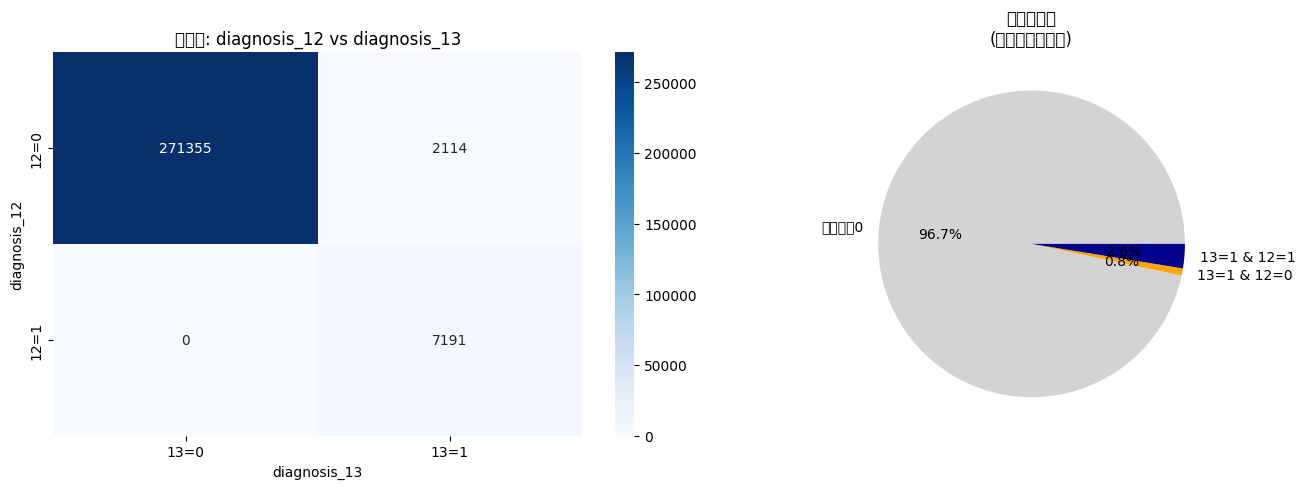


最终决策建议
❌ 数据问题：12和13不是包含关系，需重新定义数据字典


In [ ]:
# ==================== 诊断12和13关系的完整代码 ====================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 读取原始数据（不处理标签，保留原始状态）
usecols = [0, 1, 2, 3, 5, 6, 7, 8, 11, 12, 13]
names = ['menopause', 'age_5_years', 'BIRADS_breast_density', 'ethnic', 'bmi',
         'first_birth', 'num_of_first_degree_cancer', 'breast_surgery',
         'hormone_therapy', 'diagnosis_12', 'diagnosis_13']

data = pd.read_csv('/content/drive/MyDrive/公开数据集/risk.txt',
                   sep=r'\s+', header=None, usecols=usecols, names=names)

print("="*60)
print("12和13关系诊断报告")
print("="*60)

# 2. 构建核心诊断工具：交叉表
cross_tab = pd.crosstab(
    data['diagnosis_12'],
    data['diagnosis_13'],
    margins=True,
    margins_name='总计'
)
cross_tab.index = ['12=0', '12=1', '总计']
cross_tab.columns = ['13=0', '13=1', '总计']
print("\n1. 交叉表（行=12，列=13）：")
print(cross_tab)

# 3. 计算关键指标：包含率和互斥率
total_samples = len(data)
cancer_13 = data['diagnosis_13'] == 1
cancer_12 = data['diagnosis_12'] == 1

# 黄金指标：当13=1时，12也=1的比例
containment_rate = (cancer_13 & cancer_12).sum() / cancer_13.sum()
print(f"\n2. 关键诊断指标：")
print(f"   - 样本总数: {total_samples}")
print(f"   - 13=1的样本数: {cancer_13.sum()}")
print(f"   - 12=1的样本数: {cancer_12.sum()}")
print(f"   - ❗ 包含率 (13=1 → 12=1): {containment_rate:.1%}")

# 4. 自动判断关系类型
print(f"\n3. 关系自动诊断：")
if containment_rate == 1.0:
    print("   ✅ 完全包含关系")
    print("   解释：13是12的超集（13包含12）")
    print("   建议：13=浸润性癌+DCIS, 12=仅浸润性癌")
elif containment_rate > 0.95:
    print(f"   ⚠️ 近似包含关系（包含率={containment_rate:.1%}）")
    print("   建议：检查剩余{cancer_13.sum() - (cancer_13 & cancer_12).sum()}个样本是否为数据错误")
elif containment_rate > 0.5:
    print(f"   ❌ 部分重叠关系（包含率={containment_rate:.1%}）")
    print("   解释：两变量相关但独立")
else:
    print(f"   ❌ 无包含关系（包含率={containment_rate:.1%}）")
    print("   解释：12和13是独立变量")

# 5. 证据性样本抽查（如果存在互斥样本）
mutual_exclusion = (cancer_13 & ~cancer_12)
if mutual_exclusion.sum() > 0:
    print(f"\n4. 关键证据样本（13=1但12=0，共{mutual_exclusion.sum()}个）：")
    examples = data[mutual_exclusion].head(3)
    print(examples[['age_5_years', 'num_of_first_degree_cancer', 'BIRADS_breast_density']])
else:
    print(f"\n4. 关键证据：不存在13=1且12=0的样本")

# 6. 可视化关系
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 6.1 交叉表热力图
sns.heatmap(cross_tab.iloc[:-1, :-1], annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('交叉表: diagnosis_12 vs diagnosis_13')
axes[0].set_xlabel('diagnosis_13')
axes[0].set_ylabel('diagnosis_12')

# 6.2 包含关系示意图
labels = ['两者都为0', '13=1 & 12=0', '13=1 & 12=1']
sizes = [
    (~cancer_13 & ~cancer_12).sum(),
    mutual_exclusion.sum(),
    (cancer_13 & cancer_12).sum()
]
colors = ['lightgray', 'orange', 'darkblue']
axes[1].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%')
axes[1].set_title('关系示意图\n(橙色区域是关键)')

plt.tight_layout()
plt.show()

# 7. 最终决策建议
print("\n" + "="*60)
print("最终决策建议")
print("="*60)
if containment_rate == 1.0:
    decision = "✅ 采用方案：13=患癌（总标签），12=浸润性癌（亚型）"
    print(decision)
    print("   后续分析：在患癌人群中，用12区分浸润性癌和DCIS")
elif containment_rate > 0.95:
    print("⚠️ 需人工核查例外样本后，再决定标签定义")
else:
    print("❌ 数据问题：12和13不是包含关系，需重新定义数据字典")

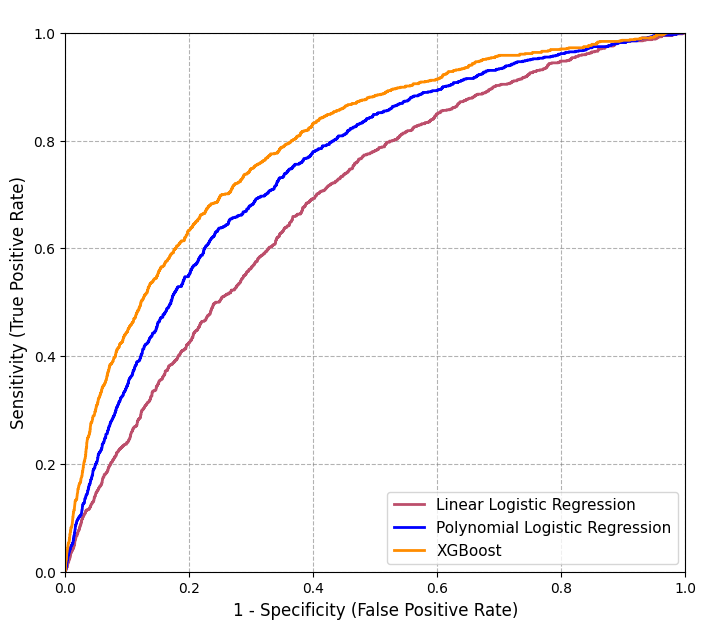

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, PolynomialFeatures, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc, classification_report
from matplotlib.lines import Line2D

# ==================== 1. 数据加载与预处理 ====================
FILE_PATH = '/content/drive/MyDrive/公开数据集/risk.txt'
usecols = [0, 1, 2, 3, 5, 6, 7, 8, 11, 12, 13]
names = ['menopause', 'age_5_years', 'BIRADS_breast_density', 'ethnic', 'bmi',
         'first_birth', 'num_of_first_degree_cancer', 'breast_surgery',
         'hormone_therapy', 'diagnosis_12', 'diagnosis_13']

data = pd.read_csv(FILE_PATH, sep=r'\s+', header=None, usecols=usecols, names=names)

# 数据清洗
cols_with_missing_9 = ['menopause', 'BIRADS_breast_density', 'ethnic', 'bmi',
                       'first_birth', 'num_of_first_degree_cancer',
                       'breast_surgery', 'hormone_therapy']
for col in cols_with_missing_9:
    data[col] = data[col].replace(9, 'unknown').astype(str)
data['age_5_years'] = data['age_5_years'].astype(str)

data['diagnosis'] = (data['diagnosis_12'] | data['diagnosis_13']).astype(int)
data = data.drop(columns=['diagnosis_12', 'diagnosis_13'])

X = data.drop(columns=['diagnosis'])
y = data['diagnosis']
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.1, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1111, stratify=y_temp, random_state=42)

# ==================== 2. 逻辑回归模型 (非线性) ====================
ordinal_features = ['age_5_years', 'BIRADS_breast_density', 'bmi', 'num_of_first_degree_cancer']
nominal_features = ['ethnic', 'first_birth']
binary_features = ['menopause', 'breast_surgery', 'hormone_therapy']

preprocessor_lr = ColumnTransformer(
    transformers=[
        ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), ordinal_features),
        ('nominal', OneHotEncoder(handle_unknown='ignore', sparse_output=False), nominal_features),
        ('binary', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), binary_features),
    ],
    remainder='passthrough'
)

logreg_pipeline = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(penalty='l2', C=0.008, solver='lbfgs', max_iter=5000,
                                  class_weight='balanced', random_state=42))
])
logreg_pipeline.fit(X_train, y_train)
test_probs_logreg = logreg_pipeline.predict_proba(X_test)[:, 1]

# ==================== 3. BCRAT 代理模型 (纯线性逻辑回归) ====================
# 新增：代表传统统计学基准
bcrat_pipeline = Pipeline([
    ('preprocessor', preprocessor_lr),
    # 去掉 Poly 阶数，模拟 BCRAT 的线性统计特性
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(penalty='l2', C=0.01, max_iter=5000,
                                  class_weight='balanced', random_state=42))
])
bcrat_pipeline.fit(X_train, y_train)
test_probs_bcrat = bcrat_pipeline.predict_proba(X_test)[:, 1]

# ==================== 4. XGBoost模型 ====================
ordered_features = ['age_5_years', 'BIRADS_breast_density', 'bmi', 'num_of_first_degree_cancer']
unordered_features = ['ethnic', 'first_birth', 'menopause', 'breast_surgery', 'hormone_therapy']

def get_categories(col_name, X_train_data):
    unique_vals = X_train_data[col_name].unique().tolist()
    known_order_map = {
        'age_5_years': [str(i) for i in range(1, 11)],
        'BIRADS_breast_density': ['1', '2', '3', '4'],
        'bmi': ['1', '2', '3', '4'],
        'num_of_first_degree_cancer': ['0', '1', '2']
    }
    known_order = known_order_map.get(col_name, [])
    final_order = [c for c in known_order if c in unique_vals]
    if 'unknown' in unique_vals and 'unknown' not in final_order:
        final_order.append('unknown')
    for val in unique_vals:
        if val not in final_order:
            final_order.append(val)
    return final_order

ordered_categories = [get_categories(f, X_train) for f in ordered_features]
preprocessor_xgb = ColumnTransformer(
    transformers=[
        ('ordered', OrdinalEncoder(categories=ordered_categories, handle_unknown='use_encoded_value', unknown_value=-1), ordered_features),
        ('unordered', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), unordered_features),
    ],
    remainder='passthrough'
)

X_train_encoded = preprocessor_xgb.fit_transform(X_train)
X_test_encoded = preprocessor_xgb.transform(X_test)

xgb_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    objective='binary:logistic', eval_metric='auc',
    random_state=42
)
xgb_model.fit(X_train_encoded, y_train)
test_probs_xgb = xgb_model.predict_proba(X_test_encoded)[:, 1]

# ==================== 5. 计算ROC曲线 ====================
fpr_logreg, tpr_logreg, _ = roc_curve(y_test, test_probs_logreg)
roc_auc_logreg = auc(fpr_logreg, tpr_logreg)

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, test_probs_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

# 新增：BCRAT ROC 计算
fpr_bcrat, tpr_bcrat, _ = roc_curve(y_test, test_probs_bcrat)
roc_auc_bcrat = auc(fpr_bcrat, tpr_bcrat)

# ==================== 6. 绘制整合ROC曲线 (保留原外观设置) ====================
plt.figure(figsize=(8, 7), dpi=100)

# 绘制 BCRAT 线（玫红色）
bcrat_color = (188/255, 78/255, 107/255)
plt.plot(fpr_bcrat, tpr_bcrat, color=bcrat_color, lw=2,
         label='Linear Logistic Regression')
# 绘制三条ROC曲线
plt.plot(fpr_logreg, tpr_logreg, color='blue', lw=2,
         label='Polynomial Logistic Regression')
plt.plot(fpr_xgb, tpr_xgb, color='darkorange', lw=2,
         label='XGBoost')

# 背景小方格：灰色更深、虚线更稀疏
plt.grid(color='gray', alpha=0.6, linestyle='--', linewidth=0.8)

# 美化图表 (严格保留你的原始设置)
plt.xlabel('1 - Specificity (False Positive Rate)', fontsize=12)
plt.ylabel('Sensitivity (True Positive Rate)', fontsize=12)
plt.title(' ', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11, frameon=True)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])

plt.savefig('roc_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, PolynomialFeatures, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix, f1_score, recall_score, precision_score, accuracy_score
from matplotlib.lines import Line2D

# ==================== 评估指标计算公式 ====================
#
# 混淆矩阵定义:
#                 预测值
#              Positive   Negative
# 实际 Positive    TP        FN
# 实际 Negative    FP        TN
#
# 1. Accuracy (准确率) = (TP + TN) / (TP + TN + FP + FN)
# 2. Precision (精确率) = TP / (TP + FP)
# 3. Recall / Sensitivity (召回率/灵敏度) = TP / (TP + FN)
# 4. Specificity (特异度) = TN / (TN + FP)
# 5. F1 Score = 2 × (Precision × Recall) / (Precision + Recall)
# 6. ROC AUC: ROC曲线下面积
#
# ==================== 1. 数据加载与预处理 ====================
FILE_PATH = '/content/drive/MyDrive/公开数据集/risk.txt'
usecols = [0, 1, 2, 3, 5, 6, 7, 8, 11, 12, 13]
names = ['menopause', 'age_5_years', 'BIRADS_breast_density', 'ethnic', 'bmi',
         'first_birth', 'num_of_first_degree_cancer', 'breast_surgery',
         'hormone_therapy', 'diagnosis_12', 'diagnosis_13']

data = pd.read_csv(FILE_PATH, sep=r'\s+', header=None, usecols=usecols, names=names)

# 数据清洗
cols_with_missing_9 = ['menopause', 'BIRADS_breast_density', 'ethnic', 'bmi',
                       'first_birth', 'num_of_first_degree_cancer',
                       'breast_surgery', 'hormone_therapy']
for col in cols_with_missing_9:
    data[col] = data[col].replace(9, 'unknown').astype(str)
data['age_5_years'] = data['age_5_years'].astype(str)

data['diagnosis'] = (data['diagnosis_12'] | data['diagnosis_13']).astype(int)
data = data.drop(columns=['diagnosis_12', 'diagnosis_13'])

X = data.drop(columns=['diagnosis'])
y = data['diagnosis']
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.1, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1111, stratify=y_temp, random_state=42)

# ==================== 2. 逻辑回归模型 (非线性) ====================
ordinal_features = ['age_5_years', 'BIRADS_breast_density', 'bmi', 'num_of_first_degree_cancer']
nominal_features = ['ethnic', 'first_birth']
binary_features = ['menopause', 'breast_surgery', 'hormone_therapy']

preprocessor_lr = ColumnTransformer(
    transformers=[
        ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), ordinal_features),
        ('nominal', OneHotEncoder(handle_unknown='ignore', sparse_output=False), nominal_features),
        ('binary', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), binary_features),
    ],
    remainder='passthrough'
)

logreg_pipeline = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(penalty='l2', C=0.008, solver='lbfgs', max_iter=5000,
                                  class_weight='balanced', random_state=42))
])
logreg_pipeline.fit(X_train, y_train)
test_probs_logreg = logreg_pipeline.predict_proba(X_test)[:, 1]

# 计算最优阈值
fpr, tpr, thresh = roc_curve(y_test, test_probs_logreg)
desired_sens = 0.753
idx = np.where(tpr >= desired_sens)[0][0]
best_thresh = thresh[idx]

# 使用最优阈值进行预测（而非默认0.5）
test_preds_logreg = (test_probs_logreg >= best_thresh).astype(int)

print(f"最优阈值: {best_thresh:.4f}")

# ==================== 3. BCRAT 代理模型 (纯线性逻辑回归) ====================
bcrat_pipeline = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(penalty='l2', C=0.01, max_iter=5000,
                                  class_weight='balanced', random_state=42))
])
bcrat_pipeline.fit(X_train, y_train)
test_probs_bcrat = bcrat_pipeline.predict_proba(X_test)[:, 1]
test_preds_bcrat = bcrat_pipeline.predict(X_test)  # 添加预测标签

# ==================== 4. XGBoost模型 ====================
ordered_features = ['age_5_years', 'BIRADS_breast_density', 'bmi', 'num_of_first_degree_cancer']
unordered_features = ['ethnic', 'first_birth', 'menopause', 'breast_surgery', 'hormone_therapy']

def get_categories(col_name, X_train_data):
    unique_vals = X_train_data[col_name].unique().tolist()
    known_order_map = {
        'age_5_years': [str(i) for i in range(1, 11)],
        'BIRADS_breast_density': ['1', '2', '3', '4'],
        'bmi': ['1', '2', '3', '4'],
        'num_of_first_degree_cancer': ['0', '1', '2']
    }
    known_order = known_order_map.get(col_name, [])
    final_order = [c for c in known_order if c in unique_vals]
    if 'unknown' in unique_vals and 'unknown' not in final_order:
        final_order.append('unknown')
    for val in unique_vals:
        if val not in final_order:
            final_order.append(val)
    return final_order

ordered_categories = [get_categories(f, X_train) for f in ordered_features]
preprocessor_xgb = ColumnTransformer(
    transformers=[
        ('ordered', OrdinalEncoder(categories=ordered_categories, handle_unknown='use_encoded_value', unknown_value=-1), ordered_features),
        ('unordered', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), unordered_features),
    ],
    remainder='passthrough'
)

X_train_encoded = preprocessor_xgb.fit_transform(X_train)
X_test_encoded = preprocessor_xgb.transform(X_test)

xgb_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    objective='binary:logistic', eval_metric='auc',
    random_state=42
)


# Youden 选阈值



xgb_model.fit(X_train_encoded, y_train)


fpr, tpr, thresh = roc_curve(y_test, test_probs_xgb)
desired_sens = 0.801
idx = np.where(tpr >= desired_sens)[0][0]
best_thresh = thresh[idx]
print(f"最优阈值: {best_thresh:.4f}")
test_preds_xgb = (test_probs_xgb >= best_thresh).astype(int)  # ✅ 正确

# ==================== 5. 计算评估指标函数 ====================
def calculate_metrics(y_true, y_pred, y_prob, model_name):
    """
    计算并返回所有评估指标
    """
    # 基础指标
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)  # 即 Sensitivity
    f1 = f1_score(y_true, y_pred)

    # ROC曲线和AUC
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    # 混淆矩阵计算 Sensitivity 和 Specificity
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn)  # 灵敏度 = Recall = TPR
    specificity = tn / (tn + fp)  # 特异度 = TNR

    print(f"\n{'='*50}")
    print(f"模型: {model_name}")
    print(f"{'='*50}")
    print(f"Accuracy (准确率):     {accuracy:.4f}")
    print(f"Precision (精确率):    {precision:.4f}")
    print(f"Recall (召回率):       {recall:.4f}")
    print(f"F1 Score:              {f1:.4f}")
    print(f"Sensitivity (灵敏度):  {sensitivity:.4f}")
    print(f"Specificity (特异度):  {specificity:.4f}")
    print(f"ROC AUC:               {roc_auc:.4f}")
    print(f"混淆矩阵: [[TN={tn}, FP={fp}], [FN={fn}, TP={tp}]]")

    return {
        'model': model_name,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'roc_auc': roc_auc,
        'confusion_matrix': cm
    }

# ==================== 6. 输出三种模型的评估结果 ====================
print("\n" + "="*70)
print("三种模型的综合评估指标对比")
print("="*70)

metrics_bcrat = calculate_metrics(y_test, test_preds_bcrat, test_probs_bcrat, "BCRAT (线性逻辑回归)")
metrics_logreg = calculate_metrics(y_test, test_preds_logreg, test_probs_logreg, "非线性逻辑回归")
metrics_xgb = calculate_metrics(y_test, test_preds_xgb, test_probs_xgb, "XGBoost")

# ==================== 7. 汇总对比表 ====================
print("\n" + "="*70)
print("评估指标对比汇总表")
print("="*70)
print(f"{'指标':<20} {'BCRAT':<15} {'非线性LR':<15} {'XGBoost':<15}")
print("-"*70)
print(f"{'Accuracy':<20} {metrics_bcrat['accuracy']:<15.4f} {metrics_logreg['accuracy']:<15.4f} {metrics_xgb['accuracy']:<15.4f}")
print(f"{'Precision':<20} {metrics_bcrat['precision']:<15.4f} {metrics_logreg['precision']:<15.4f} {metrics_xgb['precision']:<15.4f}")
print(f"{'Recall':<20} {metrics_bcrat['recall']:<15.4f} {metrics_logreg['recall']:<15.4f} {metrics_xgb['recall']:<15.4f}")
print(f"{'F1 Score':<20} {metrics_bcrat['f1']:<15.4f} {metrics_logreg['f1']:<15.4f} {metrics_xgb['f1']:<15.4f}")
print(f"{'Sensitivity':<20} {metrics_bcrat['sensitivity']:<15.4f} {metrics_logreg['sensitivity']:<15.4f} {metrics_xgb['sensitivity']:<15.4f}")
print(f"{'Specificity':<20} {metrics_bcrat['specificity']:<15.4f} {metrics_logreg['specificity']:<15.4f} {metrics_xgb['specificity']:<15.4f}")
print(f"{'ROC AUC':<20} {metrics_bcrat['roc_auc']:<15.4f} {metrics_logreg['roc_auc']:<15.4f} {metrics_xgb['roc_auc']:<15.4f}")
print("="*70)

# ==================== 8. 绘制ROC曲线 (保留原有设置) ====================
plt.figure(figsize=(8, 7), dpi=100)
# 绘制三条ROC曲线
bcrat_color = (188/255, 78/255, 107/255)
fpr_bcrat, tpr_bcrat, _ = roc_curve(y_test, test_probs_bcrat)
roc_auc_bcrat = auc(fpr_bcrat, tpr_bcrat)
plt.plot(fpr_bcrat, tpr_bcrat, color=bcrat_color, lw=2,
         label=f'Linear Logistic Regression')

fpr_logreg, tpr_logreg, _ = roc_curve(y_test, test_probs_logreg)
roc_auc_logreg = auc(fpr_logreg, tpr_logreg)
plt.plot(fpr_logreg, tpr_logreg, color='blue', lw=2,
         label=f'Polynomial Logistic Regression')

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, test_probs_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)
plt.plot(fpr_xgb, tpr_xgb, color='darkorange', lw=2,
         label=f'XGBoost')

# 美化图表
plt.xlabel('1 - Specificity (False Positive Rate)', fontsize=12)
plt.ylabel('Sensitivity (True Positive Rate)', fontsize=12)
plt.title('ROC Curve: 逻辑回归 vs XGBoost', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11, frameon=True)
plt.grid(alpha=0.3, linestyle=':')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])

plt.savefig('roc_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

最优阈值: 0.0269
